# Preprocessing - life_style_data.duckdb

## Importation des librairies essentielles

In [117]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## Nettoyage des données

### Contexte & objectifs

Ce chapitre prépare le dataset life_style_data pour la modélisation.
Objectifs :
- Corriger les types (notamment les décimales avec virgules) ;
- Quantifier et traiter les valeurs manquantes ;
- Détecter/supprimer les doublons ;
- Poser des règles de plausibilité métier (sans censurer) ;
- Produire un rapport de nettoyage et des artefacts (dataset nettoyé).

Entrée : table DuckDB life_style_data (chargée via DBeaver).
Sorties : df_clean (Parquet/CSV), tableaux de suivi (manquants, conversions, doublons, flags).

### Imports, paramètres, chargement depuis DuckDB

In [85]:
# 🔧 Définition des chemins (adaptés à ton arborescence GitHub)
# Notebook : C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks\preprocessing\life_style_data
# Base     : C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\raw\life_style_data

# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# 🗂️ Chemins complets
db_path = project_root / "src" / "data" / "raw" / "life_style_data" / "life_style_data"
export_dir = project_root / "src" / "data" / "processed" / "life_style_data"

# ✅ Connexion à la base DuckDB
con = duckdb.connect(str(db_path))

# ✅ Chargement de la table
df = con.execute("SELECT * FROM life_style_data").fetchdf()

# ✅ Vérification du chargement
shape_before = df.shape
print(f"✔ Données chargées : {shape_before[0]} lignes, {shape_before[1]} colonnes")
display(df.head(3))

✔ Données chargées : 20000 lignes, 54 colonnes


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High


### Audit qualité initial

On dresse un état des lieux :
- Répartition des types et cardinalités ;
- Valeurs manquantes (%) par colonne ;
- Doublons potentiels.

Cet instantané nous sert de référence avant toute modification.

In [86]:
# 1.2 Audit qualité initial
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
dup_count = df.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing_%": df.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"• Doublons détectés (avant): {dup_count}")
display(missing_pct.to_frame("missing_%").head(20))
display(summary_types.head(20))


• Doublons détectés (avant): 0


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


,dtype,n_unique,missing_%
Age,float64,3950,0.0
Body Part,object,7,0.0
prep_time_min,float64,5384,0.0
cook_time_min,float64,9406,0.0
rating,float64,414,0.0
Name of Exercise,object,55,0.0
Sets,float64,30,0.0
Reps,float64,654,0.0
Benefit,object,49,0.0
Burns Calories (per 30 min),float64,5766,0.0


### Correction de types (décimales à virgule, espaces insécables)

Dans de nombreux exports, les colonnes numériques arrivent en texte (object) avec :
- des virgules à la place du point décimal ;
- des espaces insécables (\u00A0) ou espaces.

On corrige proprement pour garantir la cohérence numérique.

In [87]:
# 1.3 Conversion robuste des colonnes numériques candidates (si présentes)
num_candidates = [
    "Age","Weight (kg)","Height (m)","Max_BPM","Avg_BPM","Resting_BPM",
    "Session_Duration (hours)","Fat_Percentage","Water_Intake (liters)",
    "Workout_Frequency (days/week)","BMI","Carbs","Proteins","Fats","Calories",
    "sugar_g","sodium_mg","cholesterol_mg","serving_size_g","prep_time_min","cook_time_min",
    "rating","BMI_calc","cal_from_macros","pct_carbs","protein_per_kg","pct_HRR","pct_maxHR",
    "cal_balance","lean_mass_kg","expected_burn","Burns Calories (per 30 min)","Calories_Burned"
]

convert_log = []
df_conv = df.copy()

for c in [col for col in num_candidates if col in df_conv.columns]:
    if df_conv[c].dtype == "object":
        before_na = df_conv[c].isna().sum()
        df_conv[c] = (df_conv[c]
            .astype(str)
            .str.replace(",", ".", regex=False)     # virgule ⇒ point
            .str.replace("\u00A0", "", regex=False) # espace insécable
            .str.strip()
        )
        df_conv[c] = pd.to_numeric(df_conv[c], errors="coerce")
        after_na = df_conv[c].isna().sum()
        convert_log.append({"column": c, "was_object": True, "na_before": before_na, "na_after": after_na})

convert_report = pd.DataFrame(convert_log).sort_values("column") if convert_log else pd.DataFrame(columns=["column","was_object","na_before","na_after"])
display(convert_report)


,column,was_object,na_before,na_after


### Règles de plausibilité (flags non bloquants)

On applique des bornes métier pour repérer des valeurs possiblement aberrantes.
On ne supprime pas : on flague pour informer la modélisation et documenter les décisions.

Exemples (paramétrables) :
- Age ∈ [10, 90]
- Max_BPM ∈ [80, 230]
- Session_Duration (hours) ∈ [0.1, 6]
- BMI ∈ [10, 60]

In [88]:
# 1.4 Flags de plausibilité (ne supprime rien)
df_flag = df_conv.copy()

def safe_between(s, low, high):
    return s.between(low, high) if s.notna().any() else pd.Series(False, index=s.index)

flags = {}
if "Age" in df_flag:               flags["Age_out"] = ~safe_between(df_flag["Age"], 10, 90)
if "Max_BPM" in df_flag:           flags["BPM_out"] = ~safe_between(df_flag["Max_BPM"], 80, 230)
if "Session_Duration (hours)" in df_flag: flags["SessDur_out"] = ~safe_between(df_flag["Session_Duration (hours)"], 0.1, 6)
if "BMI" in df_flag:               flags["BMI_out"] = ~safe_between(df_flag["BMI"], 10, 60)

flag_counts = {k: v.fillna(False).sum() for k, v in flags.items()}
flag_table = pd.DataFrame.from_dict(flag_counts, orient="index", columns=["nb_outliers"]).sort_index()
display(flag_table)


,nb_outliers
Age_out,0
BMI_out,0
BPM_out,0
SessDur_out,0


### Imputation des valeurs manquantes (baseline)

Stratégie simple et robuste (baseline reproductible) :
- Numériques → médiane (moins sensible aux outliers) ;
- Catégorielles → mode (valeur la plus fréquente, sinon “Unknown”).

Cette baseline est suffisante pour itérer ; on pourra spécialiser par la suite.

In [89]:
# 1.5 Imputation des manquants
df_imp = df_flag.copy()

num_cols = df_imp.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_imp.columns if c not in num_cols]

# Numériques → médiane
for c in num_cols:
    if df_imp[c].isna().any():
        df_imp[c] = df_imp[c].fillna(df_imp[c].median())

# Catégorielles → mode (ou "Unknown")
for c in cat_cols:
    if df_imp[c].isna().any():
        m = df_imp[c].mode(dropna=True)
        df_imp[c] = df_imp[c].fillna(m.iloc[0] if not m.empty else "Unknown")

missing_before = missing_pct  # gardé depuis 1.2
missing_after = df_imp.isna().mean().sort_values(ascending=False) * 100

print("✔ Imputation effectuée.")
display(pd.DataFrame({"missing_before_%": missing_before}).head(10))
display(pd.DataFrame({"missing_after_%": missing_after}).head(10))


✔ Imputation effectuée.


,missing_before_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


,missing_after_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


### Doublons & incohérences simples

On élimine les doublons stricts (lignes identiques).

Cette opération stabilise la taille du corpus et évite des biais à l’entraînement.

In [90]:
# 1.6 Doublons
rows_before = df_imp.shape[0]
dup_total = df_imp.duplicated().sum()
df_clean = df_imp.drop_duplicates().reset_index(drop=True)
rows_after = df_clean.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_clean.shape[1]]
})
display(clean_report)


,rows_before,rows_after,duplicates_removed,cols
0,20000,20000,0,54


### Rapport de nettoyage (synthèse consultant)

Nous consolidons les éléments clés pour traçabilité et communication :
- Colonnes converties object → numeric ;
- Avant/Après des valeurs manquantes ;
- Nombre de doublons supprimés ;
- Flags de plausibilité relevés.

Ce rapport sert de référence pour justifier les choix et préparer la suite (encodage, scaling).

In [91]:
# 1.7 Rapport consolidé
sections = {
    "convert_report": convert_report,
    "missing_before_% (top 20)": missing_before.to_frame("missing_%").head(20),
    "missing_after_% (top 20)": missing_after.to_frame("missing_%").head(20),
    "plausibility_flags": flag_table,
    "clean_report": clean_report
}

for title, df_sec in sections.items():
    print("\n" + "="*30 + f" {title} " + "="*30)
    display(df_sec)



============================== convert_report ==============================


,column,was_object,na_before,na_after



============================== missing_before_% (top 20) ==============================


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0



============================== missing_after_% (top 20) ==============================


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0



============================== plausibility_flags ==============================


,nb_outliers
Age_out,0
BMI_out,0
BPM_out,0
SessDur_out,0



============================== clean_report ==============================


,rows_before,rows_after,duplicates_removed,cols
0,20000,20000,0,54


### Export des artefacts (dataset nettoyé)

On persiste le dataset nettoyé pour les étapes suivantes (encodage, scaling, split) et pour reproductibilité :
- life_style_data_clean.parquet (format recommandé) ;
- Optionnel : life_style_data_clean.csv.

In [92]:
# 1.8 Export artefacts
parquet_path = export_dir / "life_style_data_clean.parquet"
# csv_path     = export_dir / "life_style_data_clean.csv"

df_clean.to_parquet(parquet_path, index=False, engine="fastparquet")
# df_clean.to_csv(csv_path, index=False)

print(f"✔ Export parquet : {parquet_path}")
# print(f"✔ Export csv     : {csv_path}")
print(f"✔ Shape final    : {df_clean.shape}")


✔ Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_clean.parquet
✔ Shape final    : (20000, 54)


### Critères d’acceptation & décisions

- Types numériques/catégoriels conformes au dictionnaire ;
- Manquants résiduels documentés et ≤ seuils tolérés (par défaut, 5%) ;
- Doublons supprimés (ou chiffrés et justifiés si conservés) ;
- Flags de plausibilité suivis (pas de censure sans décision métier explicite).

Décisions à garder au journal :
- Colonnes converties, colonnes fortement manquantes et stratégie appliquée ;
- Seuils de plausibilité retenus et impact (aucune ligne supprimée à ce stade) ;
- Lieux d’export des artefacts.

## Encodage des variables catégorielles

### Objectifs

Cette étape consiste à transformer les variables catégorielles du jeu de données nettoyé en représentations numériques exploitables par les algorithmes de Machine Learning.
L’encodage rend les colonnes qualitatives compatibles avec les modèles tout en préservant l’information sémantique.
Deux approches principales sont appliquées selon la nature des catégories :
- Encodage ordinal pour les variables hiérarchiques (ex. niveau d’expérience) ;
- Encodage one-hot pour les variables nominales (ex. type d’exercice, partie du corps, équipement).

### Chargement du dataset nettoyé

In [93]:
# Charger les artefacts nettoyés
df_clean = pd.read_parquet(parquet_path)

print(f"✔ Dataset chargé : {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")
df_clean.head(3)

✔ Dataset chargé : 20000 lignes, 54 colonnes


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High


### Identification des variables catégorielles
On repère les variables non numériques à encoder.
L’objectif est de distinguer :
- les variables nominales (non ordonnées),
- les variables ordinales (possédant une hiérarchie logique).

In [94]:
# Identification des colonnes catégorielles
cat_cols = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
print(f"🔎 {len(cat_cols)} variables catégorielles détectées :")
cat_cols


🔎 15 variables catégorielles détectées :


['Gender',
 'Workout_Type',
 'meal_name',
 'meal_type',
 'diet_type',
 'cooking_method',
 'Name of Exercise',
 'Benefit',
 'Target Muscle Group',
 'Equipment Needed',
 'Difficulty Level',
 'Body Part',
 'Type of Muscle',
 'Workout',
 'Burns_Calories_Bin']

### Encodage ordinal

Les variables catégorielles ordonnées (par ex. Experience_Level, Difficulty Level) sont converties en valeurs entières selon leur progression logique.

Cette méthode conserve la hiérarchie implicite entre les modalités.

In [95]:
# Encodage ordinal sur variables à hiérarchie logique
ordinal_features = ["Experience_Level", "Difficulty Level"]

encoder_ordinal = OrdinalEncoder()
df_clean[ordinal_features] = encoder_ordinal.fit_transform(df_clean[ordinal_features])

print("✔ Encodage ordinal appliqué sur :", ordinal_features)
df_clean[ordinal_features].head()


✔ Encodage ordinal appliqué sur : ['Experience_Level', 'Difficulty Level']


,Experience_Level,Difficulty Level
0,14.0,0.0
1,14.0,2.0
2,2.0,2.0
3,12.0,0.0
4,13.0,0.0


### Encodage One-Hot

Les variables nominales (sans hiérarchie) sont transformées par One-Hot Encoding, créant une colonne binaire par modalité.

Cela permet d’éviter toute interprétation de relation d’ordre entre catégories.

In [96]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=[col for col in cat_cols if col not in ["Experience_Level", "Difficulty Level"]],
    drop_first=True
)

print(f"✔ One-Hot Encoding appliqué : {df_encoded.shape[1]} colonnes au total")
df_encoded.head(3)


✔ One-Hot Encoding appliqué : 287 colonnes au total


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,Workout_Skull crushers,Workout_Standing calf raises,Workout_Towel pull-up,Workout_Triceps dips,Workout_Triceps pushdowns,Workout_Wrist curl,Workout_Wrist extension,Burns_Calories_Bin_Low,Burns_Calories_Bin_Medium,Burns_Calories_Bin_Very High
0,34.91,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,1.50,...,False,False,False,False,False,False,False,False,True,False
1,23.37,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,1.90,...,False,False,False,False,False,False,False,False,False,False
2,33.20,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,1.88,...,False,True,False,False,False,False,False,False,False,False


### Vérification post-encodage

Après encodage :
- Toutes les variables sont numériques ;
- Le nombre de colonnes augmente (selon le nombre de modalités) ;
- Aucun NaN ne doit être réintroduit.

In [97]:
print(f"Forme finale du dataset encodé : {df_encoded.shape}")
print(f"Valeurs manquantes totales : {df_encoded.isna().sum().sum()}")

# Aperçu d'un sous-ensemble des nouvelles colonnes encodées
df_encoded.filter(like="Workout_Type").head(5)


Forme finale du dataset encodé : (20000, 287)
Valeurs manquantes totales : 0


,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,False,True,False
1,True,False,False
2,False,False,False
3,True,False,False
4,False,True,False


### Export du dataset encodé

On exporte le jeu de données final encodé pour les étapes suivantes :
- Mise à l’échelle / normalisation
- Split train/test

In [98]:
encoded_path = export_dir / "life_style_data_encoded.parquet"
df_encoded.to_parquet(encoded_path, index=False)
print(f"✔ Export du dataset encodé : {encoded_path}")


✔ Export du dataset encodé : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_encoded.parquet


L’encodage garantit la compatibilité du jeu de données avec les algorithmes de Machine Learning.

Les variables catégorielles hiérarchiques ont été traitées par encodage ordinal, et les variables nominales par encodage one-hot, réduisant les risques de biais d’interprétation.

## Mise à l’échelle / Normalisation des variables numériques

### Objectifs

Cette étape vise à homogénéiser les échelles des variables numériques afin d’éviter qu’une variable à grande amplitude (ex. Calories ou Weight (kg)) ne domine les autres lors de l’apprentissage du modèle.
Deux techniques sont généralement utilisées :
- StandardScaler : recentre les données autour de 0 et réduit leur variance à 1 ;
- MinMaxScaler : ramène les valeurs dans un intervalle [0,1].

Le choix du scaler dépend de la nature des modèles :
- Les algorithmes linéaires ou ceux utilisant une distance (SVM, KNN, PCA) sont sensibles à l’échelle → StandardScaler privilégié ;
- Les modèles arborescents (Random Forest, XGBoost) y sont peu sensibles.

In [99]:
encoded_path = export_dir / "life_style_data_encoded.parquet"

df_encoded = pd.read_parquet(encoded_path)
print(f"✔ Dataset encodé chargé : {df_encoded.shape[0]} lignes, {df_encoded.shape[1]} colonnes")
df_encoded.head(3)

✔ Dataset encodé chargé : 20000 lignes, 287 colonnes


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,Workout_Skull crushers,Workout_Standing calf raises,Workout_Towel pull-up,Workout_Triceps dips,Workout_Triceps pushdowns,Workout_Wrist curl,Workout_Wrist extension,Burns_Calories_Bin_Low,Burns_Calories_Bin_Medium,Burns_Calories_Bin_Very High
0,34.91,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,26.800377,1.50,...,False,False,False,False,False,False,False,False,True,False
1,23.37,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,27.655021,1.90,...,False,False,False,False,False,False,False,False,False,False
2,33.20,58.98,1.67,175.04,123.95,54.96,0.91,802.26,24.320821,1.88,...,False,True,False,False,False,False,False,False,False,False


### Sélection des variables numériques

On identifie toutes les variables numériques du dataset afin d’appliquer la mise à l’échelle uniquement sur celles qui ne sont pas déjà binaires (0/1).

Les colonnes issues du One-Hot Encoding ne doivent pas être modifiées.

In [100]:
# Identifier toutes les colonnes numériques
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les colonnes binaires (issues du One-Hot Encoding)
non_binary_num_cols = [col for col in num_cols if df_encoded[col].nunique() > 2]

print(f"🔎 Variables numériques à mettre à l’échelle : {len(non_binary_num_cols)}")
non_binary_num_cols[:15]  # aperçu

🔎 Variables numériques à mettre à l’échelle : 40


['Age',
 'Weight (kg)',
 'Height (m)',
 'Max_BPM',
 'Avg_BPM',
 'Resting_BPM',
 'Session_Duration (hours)',
 'Calories_Burned',
 'Fat_Percentage',
 'Water_Intake (liters)',
 'Workout_Frequency (days/week)',
 'Experience_Level',
 'BMI',
 'Daily meals frequency',
 'Physical exercise']

### Application du StandardScaler

Le StandardScaler est appliqué sur toutes les variables continues identifiées.

Cette normalisation rend la moyenne nulle et la variance unitaire, garantissant un traitement équilibré par les algorithmes sensibles à l’échelle des features.

In [101]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_encoded[non_binary_num_cols])

# Remplacer les colonnes originales par leurs versions normalisées
df_scaled = df_encoded.copy()
df_scaled[non_binary_num_cols] = scaled_values

print("✔ Standardisation terminée.")
df_scaled[non_binary_num_cols].describe().T.head(10)

✔ Standardisation terminée.


,count,mean,std,min,25%,50%,75%,max
Age,20000.0,-4.261480e-16,1.000025,-1.721230,-0.881724,0.083665,0.889739,1.718513
Weight (kg),20000.0,7.105427e-19,1.000025,-1.639809,-0.743363,-0.184146,0.576275,2.686089
Height (m),20000.0,-4.213518e-16,1.000025,-1.834954,-0.811571,-0.103074,0.605422,2.258579
Max_BPM,20000.0,1.811884e-17,1.000025,-1.787904,-0.854193,0.021745,0.828399,1.715848
Avg_BPM,20000.0,-1.726619e-16,1.000025,-1.726623,-0.875027,-0.050066,0.866013,1.831856
Resting_BPM,20000.0,-1.524114e-16,1.000025,-1.743109,-0.855490,0.000574,0.808623,1.688010
Session_Duration (hours),20000.0,2.572165e-16,1.000025,-2.254275,-0.613623,0.030919,0.587569,2.228221
Calories_Burned,20000.0,-3.403500e-16,1.000025,-1.905552,-0.735359,-0.096890,0.543596,3.207204
Fat_Percentage,20000.0,-3.019807e-16,1.000025,-2.955980,-0.743291,-0.055806,0.715510,1.781150
Water_Intake (liters),20000.0,-2.280842e-16,1.000025,-1.930657,-0.756538,-0.028916,0.814466,1.823215


### Vérification post-normalisation

Après mise à l’échelle :
- La moyenne des colonnes est proche de 0 ;
- L’écart-type est proche de 1 ;
- Les colonnes binaires n’ont pas été modifiées.

In [102]:
# Vérification moyenne ~0 et std ~1
check_stats = df_scaled[non_binary_num_cols].agg(["mean", "std"]).T
check_stats.head(10)

,mean,std
Age,-4.261480e-16,1.000025
Weight (kg),7.105427e-19,1.000025
Height (m),-4.213518e-16,1.000025
Max_BPM,1.811884e-17,1.000025
Avg_BPM,-1.726619e-16,1.000025
Resting_BPM,-1.524114e-16,1.000025
Session_Duration (hours),2.572165e-16,1.000025
Calories_Burned,-3.403500e-16,1.000025
Fat_Percentage,-3.019807e-16,1.000025
Water_Intake (liters),-2.280842e-16,1.000025


### Export du dataset normalisé

Le dataset final normalisé est sauvegardé pour la suite du pipeline :
- life_style_data_scaled.parquet : pour la modélisation supervisée ;
- life_style_data_scaled.csv : pour inspection rapide sous DBeaver.

In [103]:
scaled_path = export_dir / "life_style_data_scaled.parquet"
# csv_scaled_path = export_dir / "life_style_data_scaled.csv"

df_scaled.to_parquet(scaled_path, index=False)
# df_scaled.to_csv(csv_scaled_path, index=False)

print(f"✔ Export parquet : {scaled_path}")
# print(f"✔ Export csv     : {csv_scaled_path}")
print(f"✔ Shape final    : {df_scaled.shape}")

✔ Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_scaled.parquet
✔ Shape final    : (20000, 287)


Critères de validation :
- Moyenne ≈ 0 et écart-type ≈ 1 pour les colonnes normalisées ;
- Aucune valeur manquante ou anormale après transformation ;
- Colonnes binaires conservées inchangées ;
- Fichiers d’export générés sans perte de structure.

Cette étape garantit une échelle cohérente entre toutes les variables continues, assurant un apprentissage plus stable et une meilleure convergence lors de la modélisation.

## Séparation features/target et split en jeux d’entraînement et de test

### Objectif

L’objectif de cette étape est de préparer les données d’apprentissage en distinguant :
- les features (X) : variables explicatives,
- la target (y) : variable cible à prédire.

Le jeu de données est ensuite découpé en deux sous-ensembles :
- Jeu d’entraînement (train set) : pour ajuster les paramètres du modèle (généralement 80 %) ;
- Jeu de test (test set) : pour évaluer sa capacité de généralisation (généralement 20 %).

Cette séparation est une pratique fondamentale du Machine Learning supervisé, garantissant la fiabilité de l’évaluation des performances.

In [107]:
scaled_path = export_dir / "life_style_data_scaled.parquet"

df_scaled = pd.read_parquet(scaled_path)

print(f"✔ Dataset normalisé chargé : {df_scaled.shape[0]} lignes, {df_scaled.shape[1]} colonnes")
df_scaled.head(3)

✔ Dataset normalisé chargé : 20000 lignes, 287 colonnes


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),...,Workout_Skull crushers,Workout_Standing calf raises,Workout_Towel pull-up,Workout_Triceps dips,Workout_Triceps pushdowns,Workout_Wrist curl,Workout_Wrist extension,Burns_Calories_Bin_Low,Burns_Calories_Bin_Medium,Burns_Calories_Bin_Very High
0,-0.325356,-0.407549,-0.811571,0.754988,0.977456,0.940325,-0.760110,-0.396661,0.139924,-1.864510,...,False,False,False,False,False,False,False,False,True,False
1,-1.277951,-0.826017,-1.362623,-0.039938,-0.837880,1.506919,0.323893,1.054924,0.310988,-1.203034,...,False,False,False,False,False,False,False,False,False,False
2,-0.466512,-0.704633,-0.417962,-0.421328,-1.384583,-0.992680,-1.023786,-0.951481,-0.356381,-1.236108,...,False,True,False,False,False,False,False,False,False,False


### Définition de la variable cible

La variable à prédire dans ce projet est Calories_Burned (y_calories_burned dans la table).

Elle représente la dépense calorique totale estimée selon les caractéristiques physiques et comportementales de l’utilisateur.

Toutes les autres colonnes servent de features (X).

In [109]:
# Identifier la colonne cible
# target_col = "y_calories_burned"
target_col = "Calories_Burned"

# Vérification que la variable existe bien
assert target_col in df_scaled.columns, f"La colonne cible {target_col} est introuvable."

# Séparation X (features) / y (target)
X = df_scaled.drop(columns=[target_col])
y = df_scaled[target_col]

print(f"✔ Features (X) : {X.shape[1]} colonnes")
print(f"✔ Target (y)   : {y.name}")

✔ Features (X) : 286 colonnes
✔ Target (y)   : Calories_Burned


### Split train/test

Le split est effectué avec un ratio standard de 80 % pour l’entraînement et 20 % pour le test, en utilisant un random_state fixe pour assurer la reproductibilité des expériences.

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"✔ Jeu d’entraînement : {X_train.shape}")
print(f"✔ Jeu de test        : {X_test.shape}")

✔ Jeu d’entraînement : (16000, 286)
✔ Jeu de test        : (4000, 286)


### Vérification statistique du split

On vérifie que :
- les proportions sont respectées (80/20),
- la distribution statistique de la variable cible reste similaire entre les deux sous-ensembles (absence de biais de séparation).

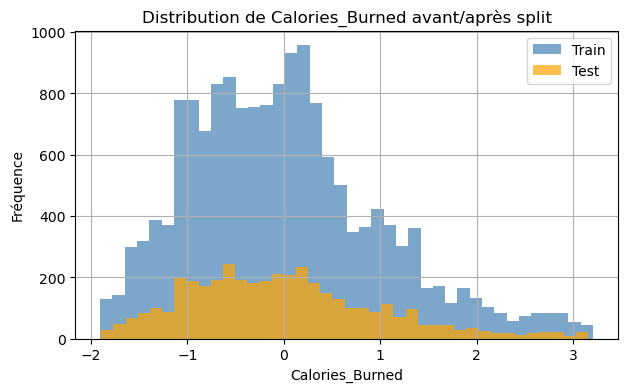

Train mean: 0.00, Test mean: -0.00


In [113]:
plt.figure(figsize=(7,4))
plt.hist(y_train, bins=40, alpha=0.7, label="Train", color="steelblue")
plt.hist(y_test, bins=40, alpha=0.7, label="Test", color="orange")
plt.legend()
plt.title("Distribution de Calories_Burned avant/après split")
plt.xlabel("Calories_Burned")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

print(f"Train mean: {y_train.mean():.2f}, Test mean: {y_test.mean():.2f}")

### Export des sous-ensembles

Les quatre sous-ensembles sont sauvegardés sous format Parquet, prêts à être utilisés pour l’entraînement et la validation des modèles.

In [ ]:
X_train.to_parquet(export_dir / "X_train.parquet", index=False)
X_test.to_parquet(export_dir / "X_test.parquet", index=False)
y_train.to_frame().to_parquet(export_dir / "y_train.parquet", index=False)
y_test.to_frame().to_parquet(export_dir / "y_test.parquet", index=False)

print("✔ Export des sous-ensembles effectué avec succès.")

✔ Export des sous-ensembles effectué avec succès.


Synthèse & critères d’acceptation :
- La variable cible Calories_Burned est correctement isolée.
- Les proportions de split sont respectées (≈ 80 % / 20 %).
- Les distributions train/test sont similaires → absence de biais de sélection.
- Les fichiers Parquet exportés garantissent la traçabilité et la reproductibilité du pipeline.

Cette étape finalise la préparation des données d’apprentissage, assurant une séparation claire entre entraînement et évaluation.

Elle constitue la base du bloc 5 — Feature Engineering et de l’entraînement des modèles supervisés.

## Sélection ou création de features pertinentes

### Objectif

Cette étape vise à optimiser la qualité des variables utilisées pour la modélisation, en éliminant les features redondantes ou peu informatives et en créant de nouvelles variables plus représentatives du phénomène étudié.

Deux approches sont utilisées :
- Sélection de features : identification des variables les plus corrélées à la cible (feature importance).
- Création de nouvelles features : dérivées ou combinaisons logiques des variables existantes (ratios, interactions, indicateurs composites).

In [116]:
X_train = pd.read_parquet(export_dir / "X_train.parquet")
y_train = pd.read_parquet(export_dir / "y_train.parquet").squeeze()  # conversion en Series

print(f"✔ Données chargées : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")

✔ Données chargées : 16000 lignes, 286 colonnes


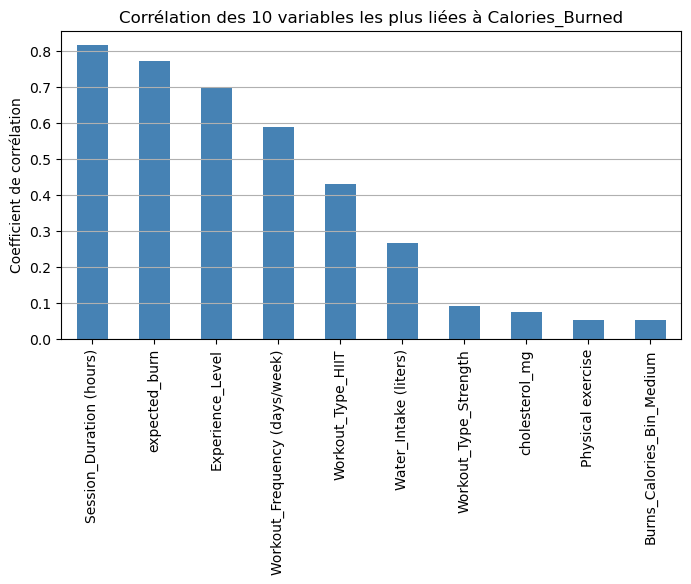

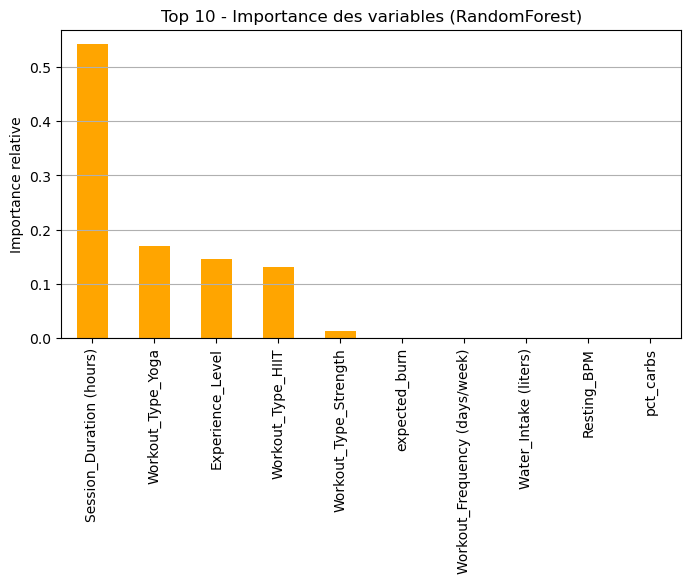

In [118]:
# Calcul des corrélations (variables continues uniquement)
corr = X_train.corrwith(y_train).dropna().sort_values(ascending=False)
top_corr = corr.head(10)

plt.figure(figsize=(8,4))
top_corr.plot(kind="bar", color="steelblue")
plt.title("Corrélation des 10 variables les plus liées à Calories_Burned")
plt.ylabel("Coefficient de corrélation")
plt.grid(True, axis='y')
plt.show()

# Modèle RandomForest pour importance des features
model_rf = RandomForestRegressor(random_state=42, n_estimators=100)
model_rf.fit(X_train, y_train)

importances = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_importances = importances.head(10)

plt.figure(figsize=(8,4))
top_importances.plot(kind="bar", color="orange")
plt.title("Top 10 - Importance des variables (RandomForest)")
plt.ylabel("Importance relative")
plt.grid(True, axis='y')
plt.show()

### Création de nouvelles features

Certaines combinaisons de variables améliorent la capacité prédictive.

On crée ici plusieurs variables dérivées liées à la physiologie et à l’activité physique :
- BPM_effort_ratio = Avg_BPM / Max_BPM
- Fat_to_weight_ratio = Fat_Percentage / Weight (kg)
- Workout_intensity = Calories_Burned / Session_Duration (hours) (proxy de rendement énergétique)
- Hydration_ratio = Water_Intake (liters) / Workout_Frequency (days/week)

In [119]:
# Création de nouvelles features
X_train = X_train.copy()

if "Avg_BPM" in X_train.columns and "Max_BPM" in X_train.columns:
    X_train["BPM_effort_ratio"] = X_train["Avg_BPM"] / X_train["Max_BPM"]

if "Fat_Percentage" in X_train.columns and "Weight (kg)" in X_train.columns:
    X_train["Fat_to_weight_ratio"] = X_train["Fat_Percentage"] / X_train["Weight (kg)"]

if "Calories_Burned" in X_train.columns and "Session_Duration (hours)" in X_train.columns:
    X_train["Workout_intensity"] = X_train["Calories_Burned"] / X_train["Session_Duration (hours)"]

if "Water_Intake (liters)" in X_train.columns and "Workout_Frequency (days/week)" in X_train.columns:
    X_train["Hydration_ratio"] = X_train["Water_Intake (liters)"] / (X_train["Workout_Frequency (days/week)"] + 1e-3)

print(f"✔ Nouvelles variables créées : {[c for c in X_train.columns if 'ratio' in c or 'intensity' in c]}")


✔ Nouvelles variables créées : ['Session_Duration (hours)', 'Workout_Concentration curls', 'BPM_effort_ratio', 'Fat_to_weight_ratio', 'Hydration_ratio']


### Réduction des features redondantes

Certaines variables peuvent être fortement corrélées entre elles, ce qui nuit à la stabilité du modèle.

On applique un filtrage basé sur la matrice de corrélation et un seuil de tolérance pour supprimer les doublons d’information.

In [120]:
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(f"🧹 Variables supprimées pour corrélation élevée (>0.95) : {len(to_drop)}")
X_train_reduced = X_train.drop(columns=to_drop, errors="ignore")


🧹 Variables supprimées pour corrélation élevée (>0.95) : 7


### Export des nouvelles données

On sauvegarde le dataset enrichi et allégé pour les étapes suivantes de modélisation supervisée.

In [121]:
feature_path = export_dir / "X_train_feature_engineered.parquet"
X_train_reduced.to_parquet(feature_path, index=False)

print(f"✔ Export du jeu de données enrichi : {feature_path}")
print(f"✔ Nombre final de colonnes : {X_train_reduced.shape[1]}")


✔ Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_train_feature_engineered.parquet
✔ Nombre final de colonnes : 282


Critères de validation :
- Identification claire des variables les plus influentes sur la cible ;
- Création de nouvelles variables pertinentes et explicables ;
- Suppression des redondances au-delà d’un seuil de corrélation de 0.95 ;
- Aucune valeur manquante introduite lors des transformations.

Cette étape améliore la qualité informationnelle du dataset et prépare le terrain pour la phase 6 – Choix et entraînement du modèle supervisé.

### Analyse de corrélation et importance des variables

On commence par une analyse de corrélation entre les variables numériques et la cible.

Cette étape permet de repérer les variables les plus influentes sur Calories_Burned.

Une méthode complémentaire basée sur un modèle de RandomForestRegressor est utilisée pour estimer l’importance relative des features.

## Code complet avec pipeline

In [104]:
# pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler()),
#     ('model', LinearRegression())
# ])

In [105]:
# pipeline.fit(X_train, y_train)

In [106]:
# y_pred = pipeline.predict(X_test)
# pd.DataFrame(y_pred,columns=['Predicted_PRICE'])